## Introduction to KNN

- **Definition:**  
  k-Nearest Neighbors (KNN) is a simple, instance-based machine learning algorithm - **For every input query, it identifies the k most similar instances from the training data and bases its prediction on their outcomes.**
  
  k-NN generalizes 1-NN: Averaging over k similar neighbors reduces sensitivity to outliers. Averaging over k neighbors helps the model cope with noise, producing a more stable and reasonable fit across the data compared to the highly variable 1-NN fit.

  The process emphasizes local information for more robust and realistic predictions, especially in the presence of noise or peculiarities in individual cases.

  - It assigns an output class to a new observation by examining the most similar observations in the training data.
  - “Similarity” is typically defined using distance metrics such as Euclidean distance.

## Intuition: How KNN Assigns Classes

- KNN evaluates the input features of a new observation and compares them with those of the training examples.
- KNN doesn't have a training phase as it memorizes the entire training dataset. KNN is a memory-based method: it retains all training data in memory.
- The algorithm looks at the K closest observations (neighbors).
- The new observation is assigned the class that is most frequent among its K nearest neighbors.
- The output is typically a mean (regression) or majority vote (classification) over the k neighbors.

**Core Idea**:  
- Given a labeled dataset (e.g., red vs. green), we store the data during training (lazy learning).
- A new data point is represented as a numeric "feature vector."
- For a new data point, we compute distances to all training points and select the **K closest** ones.  
- The majority label among those K neighbors becomes the prediction.


## Choosing the Value of K

Choosing the right value of K is crucial to the behavior and performance of the KNN classifier. Different values of K can lead to different predictions

- **Small K (e.g., K=1):**  
  - A small K can make predictions sensitive to noise (high variance, risk of overfitting).The model is highly specific to the training data.
  - Leads to **highly flexible** boundaries
  - Captures fine-grained structure, Risk: **Overfitting** (may model noise in the data).
  - Results in 100% training accuracy, but poor generalization
  - **On dense data: 1-NN predictions can track the true underlying function closely.**
  - **On sparse/noisy data: 1-NN predictions fluctuate wildly and fail to generalize.**
  - **1-NN is very sensitive to noise and performs poorly when the input data is sparse or noisy.**
  
- **Large K (e.g., K=1000):**
  - A large k creates very generalized answers (high bias, risk of underfitting). Produces smoother, simpler boundaries
  - The model becomes more generalized.
  - Risk: **Underfitting** (may overlook important patterns).
  - Generalizes better, but may underfit complex patterns

- **Key Point:**  
  - There is a trade-off between overfitting and underfitting.
  - Small k → Low bias, high variance
  - Large k → High bias, low variance
  - Both extremes are undesirable; aim for a balanced “sweet spot” that performs well on unseen data.
  - K is a smoothing parameter, and the optimal k provides a balance between variance and bias.

## Features & Feature Engineering:

- KNN requires numeric input because it uses distance calculations—feature vectors must represent each example numerically.

- Without scaling, larger features dominate the distance calculations.

- More features can improve or complicate KNN, so dimensionality reduction and careful feature selection (feature engineering) are important.

## **k-NN Process**

1. **Load the Dataset**  
   - Since k-NN does not involve a training phase, you only need the complete dataset to start.

2. **Select the Number of Neighbors (k)**  
   - Decide on the value of k representing how many neighbors to consider for classification.

3. **Identify Nearest Neighbors**  
   - Compute the distance between the test point $ t $ and every example in the training set.  
   - Sort all training points in order of increasing distance from $ t $.  
   - Select the top k closest points as the nearest neighbors.

4. **Predict the Label**  
   - Count the class labels of these k neighbors and assign the most common label to the test point $ t $.

## Lazy Learner
- KNN is often called a lazy learner. KNN does not build a model during training, but instead simply memorizes all the training data points. Whenever a prediction is needed, KNN needs to measure the distance between the test data and the memorized training data. So it takes a long time to predict.
- It's also known as instance-based learning.

### Lazy learning (instance-based learning)
- In instance-based learning, no model is built first. It simply stores all the training data and uses the stored data to make predictions on
test data or new data whenever needed.
- Instance-based learning is typically slower than model-based learning
because it must compute something between the new data points
and all training data points every time a prediction is made.
- KNN is a typical example of instance-based learning.

### Eager learning (model-based learning)
- A model is built by fitting to the training data and then used to make
predictions on the test data or new data.
- Model-based learning takes time to train, but once trained, it can
make predictions quickly. It is typically faster than instance-based
learning.
- Model-based learning often has higher prediction accuracy than
instance-based learning because the model is trained on a large
dataset and can generalize to new data.
- Most machine learning models, such as decision trees, support vector
machines, and artificial neural networks, work this way.

## Toy examples
## CLASSIFICATION: Flower Species Prediction

**Training Data** (Features: Sepal Length, Sepal Width | Label: Species)

| ID | Sepal Length (cm) | Sepal Width (cm) | Species |
|----|-------------------|------------------|---------|
| 1  | 5.1               | 3.5              | Setosa  |
| 2  | 4.9               | 3.0              | Setosa  |
| 3  | 4.7               | 3.2              | Setosa  |
| 4  | 7.0               | 3.2              | Versicolor |
| 5  | 6.4               | 3.2              | Versicolor |
| 6  | 6.9               | 3.1              | Versicolor |
| 7  | 5.5               | 2.3              | Versicolor |
| 8  | 6.5               | 2.8              | Virginica |
| 9  | 7.6               | 3.0              | Virginica |
| 10  | 6.3               | 2.5              | Virginica |
| 11  | 6.8               | 2.7              | Virginica |
| 12 | 7.2               | 3.6              | Virginica |

**New Flower to Classify**: `(6.2, 2.9)`

In [1]:
import numpy as np

In [2]:
# Training data
X_class = np.array([
    [5.1, 3.5], [4.9, 3.0], [4.7, 3.2],
    [7.0, 3.2], [6.4, 3.2], [6.9, 3.1], [5.5, 2.3],
    [6.5, 2.8], [7.6, 3.0], [6.3, 2.5], [6.8, 2.7], [7.2, 3.6]
])
y_class = np.array(['Setosa']*3 + ['Versicolor']*4 + ['Virginica']*5)

# Test data
new_point = np.array([[6.2, 2.9]])

In [4]:
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier

In [5]:
knn = NearestNeighbors(n_neighbors=5).fit(X_class)
distances, indices = knn.kneighbors(new_point)
distances, indices

(array([[0.31622777, 0.36055513, 0.41231056, 0.63245553, 0.72801099]]),
 array([[ 7,  4,  9, 10,  5]]))

In [10]:
model = KNeighborsClassifier()
model.fit(X_class,y_class)
model.predict(new_point)

array(['Virginica'], dtype='<U10')

In [7]:
from sklearn.metrics import euclidean_distances

In [9]:
np.sqrt((0.6)**2+(1.1)**2)

np.float64(1.252996408614167)

In [8]:
dist = euclidean_distances(X_class, new_point)
dist

array([[1.25299641],
       [1.30384048],
       [1.52970585],
       [0.85440037],
       [0.36055513],
       [0.72801099],
       [0.92195445],
       [0.31622777],
       [1.40356688],
       [0.41231056],
       [0.63245553],
       [1.22065556]])

In [12]:
dis_sort = np.argsort(dist, axis = 0)
dis_sort

array([[ 7],
       [ 4],
       [ 9],
       [10],
       [ 5],
       [ 3],
       [ 6],
       [11],
       [ 0],
       [ 1],
       [ 8],
       [ 2]])

In [13]:
y_class[dis_sort[:5]]

array([['Virginica'],
       ['Versicolor'],
       ['Virginica'],
       ['Virginica'],
       ['Versicolor']], dtype='<U10')

## REGRESSION: House Price Prediction

**Training Data** (Features: Size (1000 sq ft), Bedrooms | Target: Price (in 1000s))

| ID | Size | Bedrooms | Price |
|----|------|----------|-------|
| 1  | 1.5  | 3        | 300   |
| 2  | 2.0  | 3        | 320   |
| 3  | 1.8  | 2        | 290   |
| 4  | 3.0  | 4        | 450   |
| 5  | 2.5  | 3        | 380   |
| 6  | 2.8  | 4        | 420   |
| 7  | 1.9  | 2        | 310   |
| 8  | 4.0  | 5        | 550   |
| 9  | 3.5  | 4        | 480   |
| 10  | 2.2  | 3        | 350   |
| 11  | 3.2  | 4        | 460   |
| 12  | 2.7  | 3        | 400   |

**New House to Predict**: `(2.6, 3.5)`

In [15]:
# Training data
X_reg = np.array([
    [1.5, 3], [2.0, 3], [1.8, 2], [3.0, 4], [2.5, 3],
    [2.8, 4], [1.9, 2], [4.0, 5], [3.5, 4], [2.2, 3],
    [3.2, 4], [2.7, 3]
])
y_reg = np.array([300, 320, 290, 450, 380, 420, 310, 550, 480, 350, 460, 400])

# Test data
new_house = np.array([[2.6, 3.5]])

In [16]:
knn = NearestNeighbors(n_neighbors=5).fit(X_reg)
distances, indices = knn.kneighbors(new_house)
distances, indices

(array([[0.50990195, 0.50990195, 0.53851648, 0.64031242, 0.64031242]]),
 array([[11,  4,  5,  9,  3]]))

In [17]:
dist = euclidean_distances(X_reg, new_house)
dist

array([[1.2083046 ],
       [0.78102497],
       [1.7       ],
       [0.64031242],
       [0.50990195],
       [0.53851648],
       [1.65529454],
       [2.05182845],
       [1.02956301],
       [0.64031242],
       [0.78102497],
       [0.50990195]])

In [18]:
dis_sort = np.argsort(dist, axis = 0)
dis_sort

array([[ 4],
       [11],
       [ 5],
       [ 3],
       [ 9],
       [ 1],
       [10],
       [ 8],
       [ 0],
       [ 6],
       [ 2],
       [ 7]])

In [19]:
y_reg[dis_sort[:5]]

array([[380],
       [400],
       [420],
       [450],
       [350]])

In [14]:
# Prediction
y_reg[dis_sort[:5]].mean()

np.float64(400.0)

In [ ]:
KNeighborsClassifier()

In [20]:
# Training data
X_reg = np.array([
    [1500, 3], [2000, 3], [1800, 2], [3000, 4], [2500, 3],
    [2800, 4], [1900, 2], [4000, 5], [3500, 4], [2200, 3],
    [3200, 4], [2700, 3]
])
y_reg = np.array([300, 320, 290, 450, 380, 420, 310, 550, 480, 350, 460, 400])

new_house = np.array([[2.6, 3.5]])

In [21]:
knn = NearestNeighbors(n_neighbors=5).fit(X_reg)
distances, indices = knn.kneighbors(new_house)
distances, indices

(array([[1497.40008348, 1797.4006259 , 1897.40059292, 1997.40006258,
         2197.40005689]]),
 array([[0, 2, 6, 1, 9]]))

In [22]:
dist = euclidean_distances(X_reg, new_house)
dist

array([[1497.40008348],
       [1997.40006258],
       [1797.4006259 ],
       [2997.4000417 ],
       [2497.40005005],
       [2797.40004468],
       [1897.40059292],
       [3997.40028143],
       [3497.40003574],
       [2197.40005689],
       [3197.40003909],
       [2697.40004634]])

In [23]:
dis_sort = np.argsort(dist, axis = 0)
dis_sort

array([[ 0],
       [ 2],
       [ 6],
       [ 1],
       [ 9],
       [ 4],
       [11],
       [ 5],
       [ 3],
       [10],
       [ 8],
       [ 7]])

In [24]:
# Prediction
y_reg[dis_sort[:5]].mean()

np.float64(314.0)

In [25]:
from sklearn.datasets import load_iris

In [29]:
data = load_iris()
data["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [20]:
import matplotlib.pyplot as plt

# Visualizing KNN – Example

### Iris Dataset: KNN Classification

Suppose we have three classes in the Iris dataset:
- Class 0: Setosa
- Class 1: Versicolor
- Class 2: Virginica

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [4]:
X, y = load_iris().data, load_iris().target
X.shape, y.shape

((150, 4), (150,))

In [33]:
np.insert(X,4,y,axis=1)

array([[5.1, 3.5, 1.4, 0.2, 0. ],
       [4.9, 3. , 1.4, 0.2, 0. ],
       [4.7, 3.2, 1.3, 0.2, 0. ],
       [4.6, 3.1, 1.5, 0.2, 0. ],
       [5. , 3.6, 1.4, 0.2, 0. ],
       [5.4, 3.9, 1.7, 0.4, 0. ],
       [4.6, 3.4, 1.4, 0.3, 0. ],
       [5. , 3.4, 1.5, 0.2, 0. ],
       [4.4, 2.9, 1.4, 0.2, 0. ],
       [4.9, 3.1, 1.5, 0.1, 0. ],
       [5.4, 3.7, 1.5, 0.2, 0. ],
       [4.8, 3.4, 1.6, 0.2, 0. ],
       [4.8, 3. , 1.4, 0.1, 0. ],
       [4.3, 3. , 1.1, 0.1, 0. ],
       [5.8, 4. , 1.2, 0.2, 0. ],
       [5.7, 4.4, 1.5, 0.4, 0. ],
       [5.4, 3.9, 1.3, 0.4, 0. ],
       [5.1, 3.5, 1.4, 0.3, 0. ],
       [5.7, 3.8, 1.7, 0.3, 0. ],
       [5.1, 3.8, 1.5, 0.3, 0. ],
       [5.4, 3.4, 1.7, 0.2, 0. ],
       [5.1, 3.7, 1.5, 0.4, 0. ],
       [4.6, 3.6, 1. , 0.2, 0. ],
       [5.1, 3.3, 1.7, 0.5, 0. ],
       [4.8, 3.4, 1.9, 0.2, 0. ],
       [5. , 3. , 1.6, 0.2, 0. ],
       [5. , 3.4, 1.6, 0.4, 0. ],
       [5.2, 3.5, 1.5, 0.2, 0. ],
       [5.2, 3.4, 1.4, 0.2, 0. ],
       [4.7, 3

In [6]:
import numpy as np
data_arr = np.hstack((X, np.expand_dims(y, axis = 1)))
data_arr

array([[5.1, 3.5, 1.4, 0.2, 0. ],
       [4.9, 3. , 1.4, 0.2, 0. ],
       [4.7, 3.2, 1.3, 0.2, 0. ],
       [4.6, 3.1, 1.5, 0.2, 0. ],
       [5. , 3.6, 1.4, 0.2, 0. ],
       [5.4, 3.9, 1.7, 0.4, 0. ],
       [4.6, 3.4, 1.4, 0.3, 0. ],
       [5. , 3.4, 1.5, 0.2, 0. ],
       [4.4, 2.9, 1.4, 0.2, 0. ],
       [4.9, 3.1, 1.5, 0.1, 0. ],
       [5.4, 3.7, 1.5, 0.2, 0. ],
       [4.8, 3.4, 1.6, 0.2, 0. ],
       [4.8, 3. , 1.4, 0.1, 0. ],
       [4.3, 3. , 1.1, 0.1, 0. ],
       [5.8, 4. , 1.2, 0.2, 0. ],
       [5.7, 4.4, 1.5, 0.4, 0. ],
       [5.4, 3.9, 1.3, 0.4, 0. ],
       [5.1, 3.5, 1.4, 0.3, 0. ],
       [5.7, 3.8, 1.7, 0.3, 0. ],
       [5.1, 3.8, 1.5, 0.3, 0. ],
       [5.4, 3.4, 1.7, 0.2, 0. ],
       [5.1, 3.7, 1.5, 0.4, 0. ],
       [4.6, 3.6, 1. , 0.2, 0. ],
       [5.1, 3.3, 1.7, 0.5, 0. ],
       [4.8, 3.4, 1.9, 0.2, 0. ],
       [5. , 3. , 1.6, 0.2, 0. ],
       [5. , 3.4, 1.6, 0.4, 0. ],
       [5.2, 3.5, 1.5, 0.2, 0. ],
       [5.2, 3.4, 1.4, 0.2, 0. ],
       [4.7, 3

In [7]:
cols = load_iris().feature_names + ['target']
cols

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)',
 'target']

In [8]:
import pandas as pd
data = pd.DataFrame(data_arr, columns = load_iris().feature_names + ['target'])
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


<Axes: >

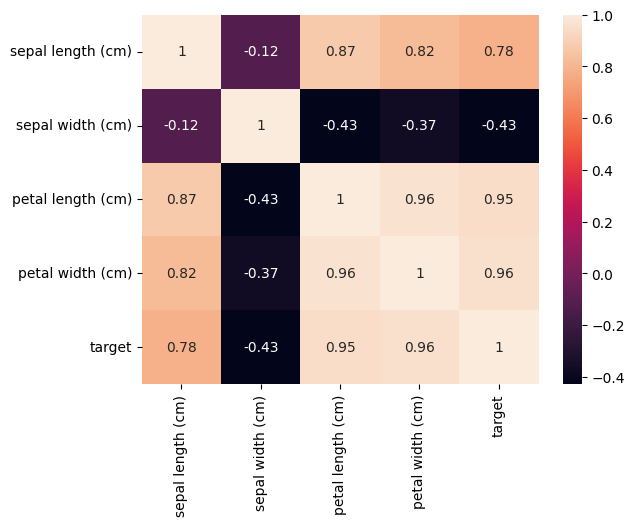

In [9]:
import seaborn as sns
corr_coeff = data.corr()
sns.heatmap(corr_coeff, annot = True)

In [10]:
data_corr = data.drop(['sepal length (cm)', 'sepal width (cm)'], axis = 1)
data_corr.head()

,petal length (cm),petal width (cm),target
0,1.4,0.2,0.0
1,1.4,0.2,0.0
2,1.3,0.2,0.0
3,1.5,0.2,0.0
4,1.4,0.2,0.0


In [11]:
X = data_corr.drop('target', axis = 1)
y = data_corr['target']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25,random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((112, 2), (38, 2), (112,), (38,))

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_transformed = scaler.fit_transform(X_train)
X_train_transformed

array([[0.05357143, 0.04166667],
       [0.07142857, 0.        ],
       [0.71428571, 0.75      ],
       [0.60714286, 0.625     ],
       [0.64285714, 0.58333333],
       [0.03571429, 0.125     ],
       [0.07142857, 0.04166667],
       [0.46428571, 0.375     ],
       [0.71428571, 0.58333333],
       [0.78571429, 0.70833333],
       [0.58928571, 0.54166667],
       [0.89285714, 1.        ],
       [0.55357143, 0.5       ],
       [0.98214286, 0.83333333],
       [0.60714286, 0.58333333],
       [0.05357143, 0.04166667],
       [1.        , 0.79166667],
       [0.53571429, 0.375     ],
       [0.05357143, 0.04166667],
       [0.03571429, 0.08333333],
       [0.14285714, 0.125     ],
       [0.42857143, 0.375     ],
       [0.67857143, 0.70833333],
       [0.14285714, 0.04166667],
       [0.08928571, 0.04166667],
       [0.10714286, 0.16666667],
       [0.55357143, 0.5       ],
       [0.07142857, 0.04166667],
       [0.55357143, 0.45833333],
       [1.        , 0.875     ],
       [0.

In [28]:
knn = KNeighborsClassifier(n_neighbors = 3, metric = 'minkowski', p = 1, n_jobs = -1)
knn

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",1
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [29]:
knn.fit(X_train_transformed, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",1
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [30]:
X_test_transformed = scaler.transform(X_test)
X_test_transformed

array([[ 0.64285714,  0.45833333],
       [ 0.10714286,  0.08333333],
       [ 1.03571429,  0.91666667],
       [ 0.60714286,  0.58333333],
       [ 0.66071429,  0.54166667],
       [ 0.07142857,  0.125     ],
       [ 0.44642857,  0.5       ],
       [ 0.71428571,  0.91666667],
       [ 0.60714286,  0.58333333],
       [ 0.5       ,  0.45833333],
       [ 0.71428571,  0.79166667],
       [ 0.05357143,  0.        ],
       [ 0.03571429,  0.04166667],
       [ 0.07142857,  0.        ],
       [ 0.07142857,  0.08333333],
       [ 0.64285714,  0.625     ],
       [ 0.83928571,  0.875     ],
       [ 0.5       ,  0.41666667],
       [ 0.60714286,  0.5       ],
       [ 0.80357143,  0.875     ],
       [ 0.08928571,  0.04166667],
       [ 0.67857143,  0.70833333],
       [ 0.08928571,  0.125     ],
       [ 0.80357143,  0.83333333],
       [ 0.94642857,  0.79166667],
       [ 0.73214286,  0.91666667],
       [ 0.83928571,  0.70833333],
       [ 0.85714286,  0.91666667],
       [ 0.05357143,

In [31]:
knn.score(X_train_transformed, y_train)

0.9732142857142857

In [32]:
y_pred = knn.predict(X_test_transformed)
y_pred

array([1., 0., 2., 1., 1., 0., 1., 2., 1., 1., 2., 0., 0., 0., 0., 1., 2.,
       1., 1., 2., 0., 2., 0., 2., 2., 2., 2., 2., 0., 0., 0., 0., 1., 0.,
       0., 2., 1., 0.])

In [19]:
from sklearn.metrics import accuracy_score

In [33]:
accuracy_score(y_test,y_pred)

1.0

In [25]:
# Set up mesh grid for decision boundary
x_min, x_max = X_train_transformed[:, 0].min() - 0.1, X_train_transformed[:, 0].max() + 0.1
y_min, y_max = X_train_transformed[:, 1].min() - 0.1, X_train_transformed[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
xx, yy

(array([[-0.1       , -0.09598662, -0.09197324, ...,  1.09197324,
          1.09598662,  1.1       ],
        [-0.1       , -0.09598662, -0.09197324, ...,  1.09197324,
          1.09598662,  1.1       ],
        [-0.1       , -0.09598662, -0.09197324, ...,  1.09197324,
          1.09598662,  1.1       ],
        ...,
        [-0.1       , -0.09598662, -0.09197324, ...,  1.09197324,
          1.09598662,  1.1       ],
        [-0.1       , -0.09598662, -0.09197324, ...,  1.09197324,
          1.09598662,  1.1       ],
        [-0.1       , -0.09598662, -0.09197324, ...,  1.09197324,
          1.09598662,  1.1       ]], shape=(300, 300)),
 array([[-0.1       , -0.1       , -0.1       , ..., -0.1       ,
         -0.1       , -0.1       ],
        [-0.09598662, -0.09598662, -0.09598662, ..., -0.09598662,
         -0.09598662, -0.09598662],
        [-0.09197324, -0.09197324, -0.09197324, ..., -0.09197324,
         -0.09197324, -0.09197324],
        ...,
        [ 1.09197324,  1.09197324,  

In [26]:
# Predict class labels for each point in the mesh
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
Z

array([[0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 2., 2., 2.],
       [1., 1., 1., ..., 2., 2., 2.],
       [1., 1., 1., ..., 2., 2., 2.]], shape=(300, 300))

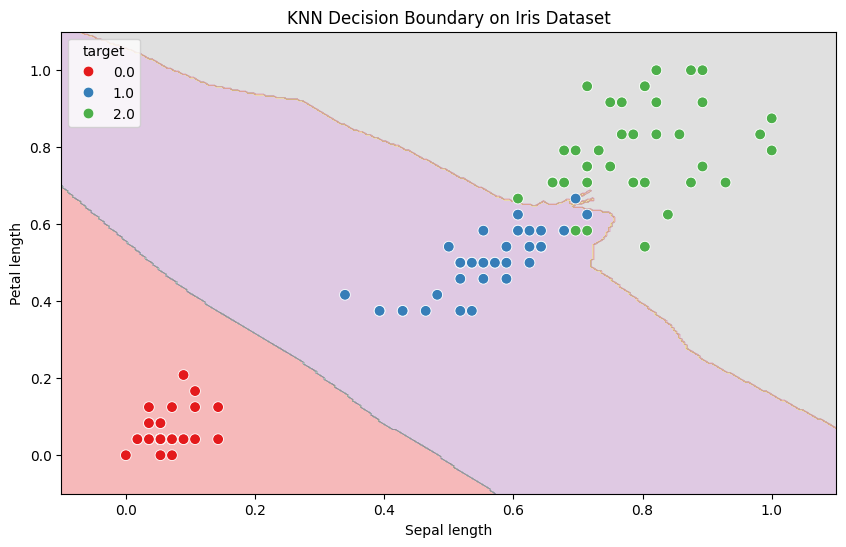

In [27]:
import matplotlib.pyplot as plt
# Plotting the decision boundary and data points
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
sns.scatterplot(x=X_train_transformed[:, 0], y=X_train_transformed[:, 1], hue=y_train, palette='Set1', s=60)
plt.xlabel('Sepal length')
plt.ylabel('Petal length')
plt.title('KNN Decision Boundary on Iris Dataset')
plt.legend(title='target')
plt.show()

In [159]:
X_test_transformed = scaler.transform(X_test)
X_test_transformed

array([[0.52941176, 0.36363636],
       [0.41176471, 0.81818182],
       [1.        , 0.27272727],
       [0.5       , 0.40909091],
       [0.73529412, 0.36363636],
       [0.32352941, 0.63636364],
       [0.38235294, 0.40909091],
       [0.76470588, 0.5       ],
       [0.55882353, 0.09090909],
       [0.44117647, 0.31818182],
       [0.64705882, 0.54545455],
       [0.14705882, 0.45454545],
       [0.35294118, 0.68181818],
       [0.17647059, 0.5       ],
       [0.23529412, 0.81818182],
       [0.58823529, 0.59090909],
       [0.64705882, 0.45454545],
       [0.38235294, 0.22727273],
       [0.41176471, 0.36363636],
       [0.61764706, 0.36363636],
       [0.11764706, 0.54545455],
       [0.52941176, 0.45454545],
       [0.20588235, 0.63636364],
       [0.61764706, 0.36363636],
       [1.05882353, 0.81818182],
       [0.70588235, 0.45454545],
       [0.70588235, 0.22727273],
       [0.73529412, 0.54545455],
       [0.14705882, 0.45454545],
       [0.14705882, 0.5       ],
       [0.

In [160]:
y_pred = knn.predict(X_test_transformed)
y_pred

array([1., 0., 2., 1., 2., 0., 1., 2., 1., 1., 2., 0., 0., 0., 0., 2., 2.,
       1., 1., 2., 0., 1., 0., 2., 2., 2., 1., 2., 0., 0., 0., 0., 2., 0.,
       0., 1., 2., 0.])

In [161]:
accuracy_score(y_pred, y_test)

0.8157894736842105

## Strengths of KNN

- **Advantages:**
  - Very simple and intuitive.
  - There is no explicit training phase—it's a "lazy learner."
  - Non-parametric: makes no assumptions about the underlying data distribution.
  - Can be used for both **classification** and **regression** tasks.
  - Easy to implement and understand.

- **Selecting K:**
  - Crucial for model performance.
  - Increasing K smooths predictions by averaging over more neighbors.

## Step by step implementation

#### Step 1 — Understand the Goal

KNN predicts the class of a new data point by:

1. Calculating distance from the new point to all training points
2. Finding the K nearest neighbors
3. Taking the majority class

#### Step 2 — Import Libraries

In [2]:
import numpy as np
import pandas as pd
from collections import Counter

#### Step 3 — Create Dataset

In [3]:
data = pd.DataFrame({
    "age":[25,30,35,40,45,50],
    "salary":[40000,50000,60000,70000,80000,90000],
    "purchased":["No","No","Yes","Yes","Yes","Yes"]
})

data

,age,salary,purchased
0,25,40000,No
1,30,50000,No
2,35,60000,Yes
3,40,70000,Yes
4,45,80000,Yes
5,50,90000,Yes


#### Step 4 — Separate Features and Target

In [4]:
X = data[["age","salary"]].values
y = data["purchased"].values

#### Step 5 — Create Distance Function

Most commonly used distance:

**Euclidean Distance**

Formula:
    distance=(x1−x2)2+(y1−y2)2

In [5]:
def euclidean_distance(a,b):
    return np.sqrt(np.sum((a-b)**2))

#### Step 6 — Compute Distance From Test Point

In [6]:
test_point = np.array([33,55000])

In [7]:
## calculating distance
distances = []

for i in range(len(X)):
    dist = euclidean_distance(test_point, X[i])
    distances.append(dist)

distances

[np.float64(15000.002133333182),
 np.float64(5000.000899999919),
 np.float64(5000.000399999984),
 np.float64(15000.001633333244),
 np.float64(25000.002879999833),
 np.float64(35000.004128571185)]

#### Step 7 — Get K Nearest Neighbors

Choose K = 3

In [9]:
k = 3

nearest_indices = np.argsort(distances)[:k]

nearest_indices

array([2, 1, 3])

#### Step 8 — Get Neighbor Classes

In [10]:
nearest_labels = y[nearest_indices]

nearest_labels

array(['Yes', 'No', 'Yes'], dtype=object)

#### Step 9 — Majority Voting

In [11]:
prediction = Counter(nearest_labels).most_common(1)[0][0]

prediction

'Yes'

In [15]:
Counter(nearest_labels).most_common(1)

[('Yes', 2)]

#### Step 10 — Wrap Everything into a Function

In [16]:
def knn_predict(X,y,test_point,k=3):
    
    distances = []
    
    for i in range(len(X)):
        dist = np.sqrt(np.sum((test_point - X[i])**2))
        distances.append(dist)
        
    nearest_indices = np.argsort(distances)[:k]
    
    nearest_labels = y[nearest_indices]
    
    prediction = Counter(nearest_labels).most_common(1)[0][0]
    
    return prediction

#### Step 11 — Test the Model

In [17]:
test = np.array([33,55000])

knn_predict(X,y,test,k=3)

'Yes'